In [1]:
import pandas as pd


In [3]:
#load the dataset
df = pd.read_csv('/kaggle/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
 # First look
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Churn'].value_counts())

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customer

In [5]:
# ---- STEP 1: Expose hidden blank spaces in TotalCharges ----
df['TotalCharges'] = df['TotalCharges'].str.strip()
df['TotalCharges'] = df['TotalCharges'].replace('', float('nan'))

# How many blank spaces were hiding?
print("Hidden blanks found:", df['TotalCharges'].isnull().sum())

# ---- STEP 2: Convert TotalCharges to a number ----
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# ---- STEP 3: Drop the rows with missing TotalCharges ----
df = df.dropna(subset=['TotalCharges'])
print("Rows after cleaning:", df.shape[0])

# ---- STEP 4: Fix SeniorCitizen to Yes/No ----
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# ---- STEP 5: Confirm everything is fixed ----
print("\nUpdated Data Types:")
print(df[['TotalCharges', 'SeniorCitizen']].dtypes)
print("\nSeniorCitizen Values:", df['SeniorCitizen'].unique())

Hidden blanks found: 11
Rows after cleaning: 7032

Updated Data Types:
TotalCharges     float64
SeniorCitizen     object
dtype: object

SeniorCitizen Values: ['No' 'Yes']


In [6]:
#Save cleaned dataset
df.to_csv('Telco-Customer-Churn-Cleaned.csv', index=False)
print("cleaned dataset saved successfully!")


cleaned dataset saved successfully!


In [7]:
# @title
#Now, moving on to the analysis questions
# Overall Churn Rate
churn_counts = df['Churn'].value_counts()
# Convert all counts to decimal; in order to be multiplied by 100 as percentage.
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts: ", churn_counts)
print("\nChurn Rate (%): ")
print(churn_rate.round(2))

Churn Counts:  Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate (%): 
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


In [8]:
# @title
#How does contract type affect churn?
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Contract Type (%):")
print(contract_churn.round(2))


Churn Rate by Contract Type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


In [9]:
# @title
# Does Tenure affect churn?

# Tenure is a numeric column — it measures how many months a customer has been with the company.
# Tenure has to be divided in ranges, since it is not a group-like column for categorical grouping.

# Step 1 - Create Tenure Groups
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 23, 24, 48, 72],
                            labels=['0-12 months',
                                    '13-24 months',
                                    '25-48 months',
                                    '49-72 months'])

# Step 2 - Calculate churn rate by tenure group
tenure_churn = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Tenure Group (%):")
print(tenure_churn.round(2))

Churn Rate by Tenure Group (%):
Churn            No    Yes
tenure_group              
0-12 months   57.87  42.13
13-24 months  75.53  24.47
25-48 months  79.61  20.39
49-72 months  90.49   9.51


/tmp/ipykernel_1974/586209371.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100


In [10]:
# @title
# Do customers with higher monthly charge churn more?
# Also, what makes customers have varying monthly charge? - Services rendered
# Why are the monthly charges higher for some other cutomers? Can it be subsidized?
# Streaming Services, Tech Support, etc.

# Step 1 - Create monthly charge groups
df['charge_group'] = pd.cut(df['MonthlyCharges'], bins=[0, 30, 60, 90, 120], labels=["Low [$ 0-30]", "Medium [$ 30-60]", "High [$ 60-90]", "Very High [$ 90-120]"])

# Step 2 - Show the churn by groups
charge_churn = df.groupby('charge_group')['Churn'].value_counts(normalize=True).unstack() *100

print("Churn Rate by monthly group (%):")
print(charge_churn.round(2))

Churn Rate by monthly group (%):
Churn                    No    Yes
charge_group                      
Low [$ 0-30]          90.16   9.84
Medium [$ 30-60]      74.03  25.97
High [$ 60-90]        66.05  33.95
Very High [$ 90-120]  67.22  32.78


/tmp/ipykernel_1974/2280952478.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charge_churn = df.groupby('charge_group')['Churn'].value_counts(normalize=True).unstack() *100


In [11]:
# Does gender affect churn rate?

gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by gender (%):")
print(gender_churn.round(2))

Churn rate by gender (%):
Churn      No    Yes
gender              
Female  73.04  26.96
Male    73.80  26.20


In [12]:
# Do streaming customers churn more?

# StreamingMovies vs Churn
streamingmovies_churn = df.groupby('StreamingMovies')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Streaming Movies (%): ")
print(streamingmovies_churn.round(2))

# StreamingTV vs Churn
streamingTV_churn = df.groupby('StreamingTV')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Streaming TV (%): ")
print(streamingTV_churn.round(2))

Churn Rate by Streaming Movies (%): 
Churn                   No    Yes
StreamingMovies                  
No                   66.27  33.73
No internet service  92.57   7.43
Yes                  70.05  29.95
Churn Rate by Streaming TV (%): 
Churn                   No    Yes
StreamingTV                      
No                   66.46  33.54
No internet service  92.57   7.43
Yes                  69.89  30.11


In [13]:
# Does payment method affect churn?

payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Payment Method (%):")
print(payment_churn.round(2))

Churn Rate by Payment Method (%):
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


In [14]:
# Are senior ciizens more likely to churn?

senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Senior Citizen Status (%):")
print(senior_churn.round(2))

Churn Rate by Senior Citizen Status (%):
Churn             No    Yes
SeniorCitizen              
No             76.35  23.65
Yes            58.32  41.68


In [15]:
# Do customers without online security churn more?

# Filter out customers with no internet service first
internet_customers = df[df['InternetService'] != 'No']

# Now check online security vs churn among internet customers only
security_churn = internet_customers.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Online Security (Internet Customers Only) (%):")
print(security_churn.round(2))


Churn Rate by Online Security (Internet Customers Only) (%):
Churn              No    Yes
OnlineSecurity              
No              58.22  41.78
Yes             85.36  14.64


In [16]:
# Do customers without online backup churn more?

# Filter out customers with no internet service first
internet_customers = df[df['InternetService'] != 'No']

# Now check online security vs churn among internet customers only
backup_churn = internet_customers.groupby('OnlineBackup')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Online Backup (Internet Customers Only) (%):")
print(backup_churn.round(2))

Churn Rate by Online Backup (Internet Customers Only) (%):
Churn            No    Yes
OnlineBackup              
No            60.06  39.94
Yes           78.43  21.57


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set hte visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

# Chart 1 - Overall Churn Rate

Chart 1 saved succcessfully!


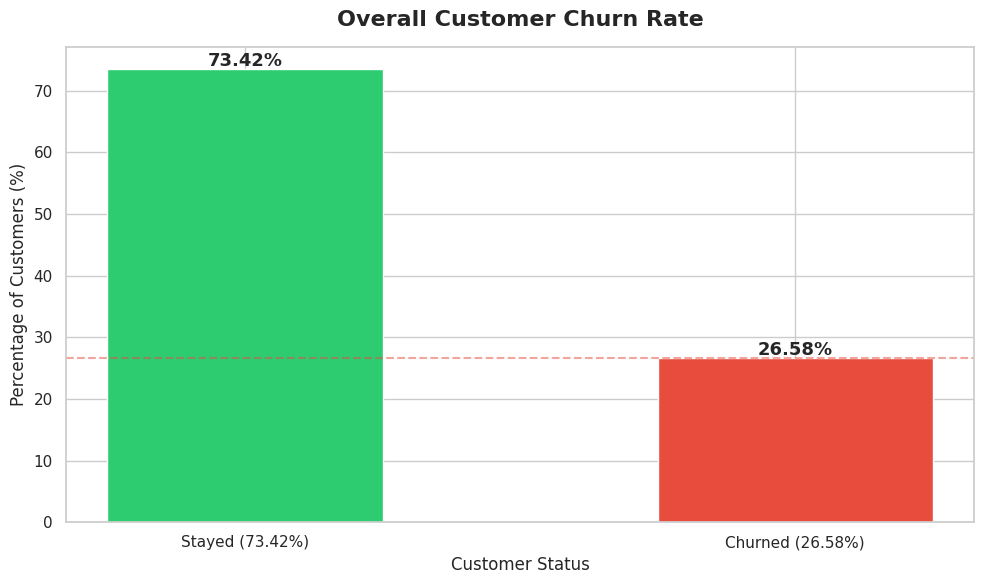

In [18]:
# Chart 1 - Overall Churn Rate

# Data
churn_labels = ['Stayed (73.42%)', 'Churned (26.58%)']
churn_values = [73.42, 26.58]
colors = ['#2ecc71', '#e74c3c']

# Build the Chart
fig, ax = plt.subplots()
ax.bar(churn_labels, churn_values, color=colors, width=0.5)

# Lables and Titles
ax.set_title('Overall Customer Churn Rate', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Percentage of Customers (%)', fontsize=12)
ax.set_xlabel('Customer Status', fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(churn_values):
  ax.text(i, v + 0.5, f'{v}%', ha='center', fontsize=13, fontweight='bold')

# Add a reference line at overall churn rate
ax.axhline(y=26.58, color='#e74c3c', linestyle='--', alpha=0.5, label='Churn Rate (26.58%)')
ax.legend

plt.tight_layout()
plt.savefig('chart1_overall_churn.png', dpi=150)
plt.show

print("Chart 1 saved succcessfully!")

# Chart 2 - Contract Type vs Churn

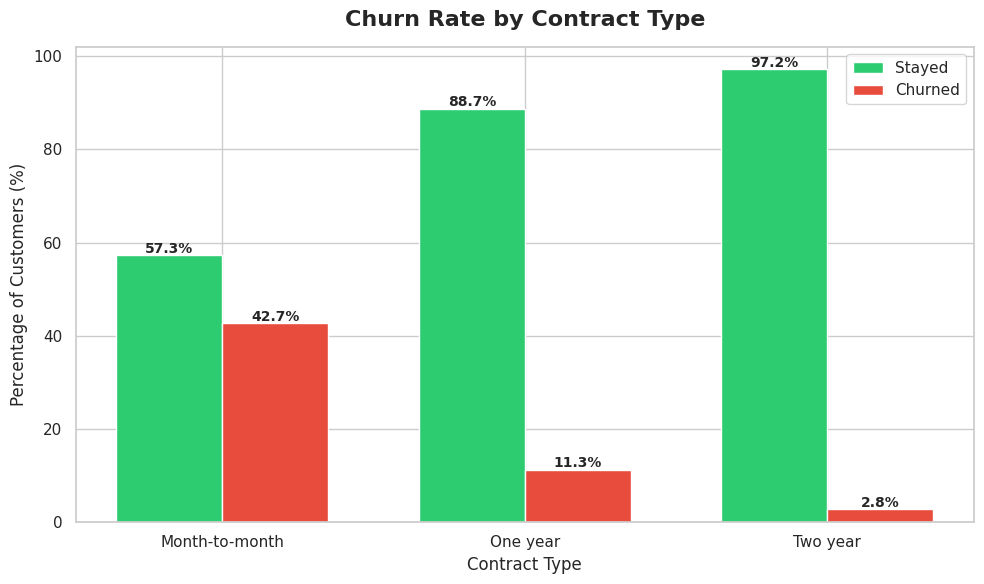

Chart 2 saved successfully!


In [19]:

# Chart 2 - Contract Type vs Churn

# Data
contract_data = contract_churn.reset_index()
categories = contract_data['Contract']
stayed = contract_data['No']
churned = contract_data['Yes']

x = range(len(categories))
width = 0.35

# Build the chart
fig, ax = plt.subplots()
bars1 = ax.bar([i - width/2 for i in x], stayed, width,
                label='Stayed', color='#2ecc71')
bars2 = ax.bar([i + width/2 for i in x], churned, width,
                label='Churned', color='#e74c3c')

# Labels and titles
ax.set_title('Churn Rate by Contract Type', fontsize=16,
              fontweight='bold', pad=15)
ax.set_ylabel('Percentage of Customers (%)', fontsize=12)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10,
            fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10,
            fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_contract_churn.png', dpi=150)
plt.show()

print("Chart 2 saved successfully!")


# Chart 3 - Tenure vs Churn (Line Chart)

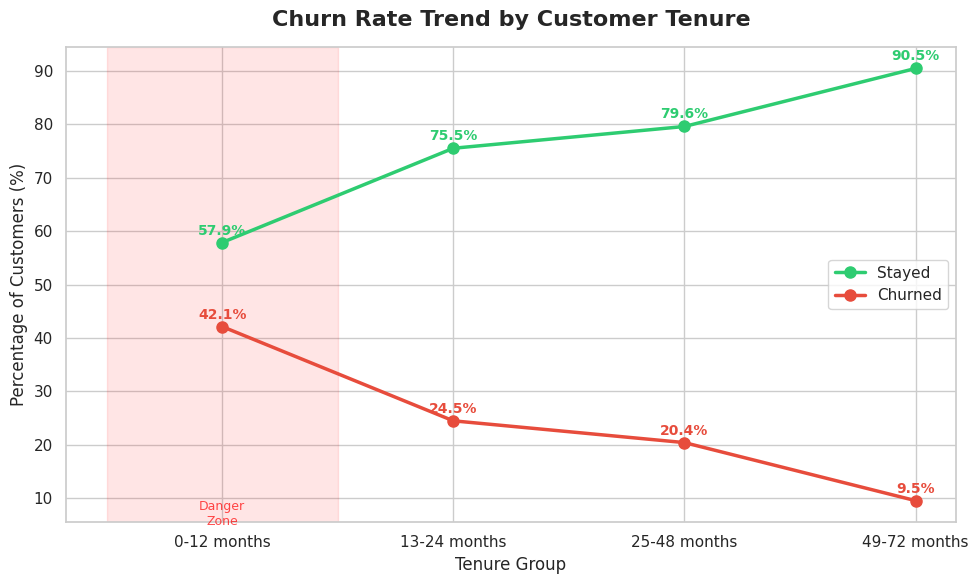

Chart 3 saved successfully!


In [20]:
# Chart 3 - Tenure vs Churn (Line Chart)

# Data
tenure_data = tenure_churn.reset_index()
categories = tenure_data['tenure_group']
stayed = tenure_data['No']
churned = tenure_data['Yes']

# Build the chart
fig, ax = plt.subplots()
ax.plot(categories, stayed, marker='o', linewidth=2.5,
        color='#2ecc71', label='Stayed', markersize=8)
ax.plot(categories, churned, marker='o', linewidth=2.5,
        color='#e74c3c', label='Churned', markersize=8)

# Add value labels on each point
for i, (s, c) in enumerate(zip(stayed, churned)):
    ax.text(i, s + 1.5, f'{s:.1f}%', ha='center',
            fontsize=10, fontweight='bold', color='#2ecc71')
    ax.text(i, c + 1.5, f'{c:.1f}%', ha='center',
            fontsize=10, fontweight='bold', color='#e74c3c')

# Labels and titles
ax.set_title('Churn Rate Trend by Customer Tenure', fontsize=16,
              fontweight='bold', pad=15)
ax.set_ylabel('Percentage of Customers (%)', fontsize=12)
ax.set_xlabel('Tenure Group', fontsize=12)
ax.legend()

# Shade the danger zone
ax.axvspan(-0.5, 0.5, alpha=0.1, color='red', label='Danger Zone')
ax.text(0, 5, 'Danger\nZone', ha='center', fontsize=9,
        color='red', alpha=0.7)

plt.tight_layout()
plt.savefig('chart3_tenure_churn.png', dpi=150)
plt.show()

print("Chart 3 saved successfully!")

# Chart 4 - Payment Method vs Churn (Horizontal Stacked Bar)

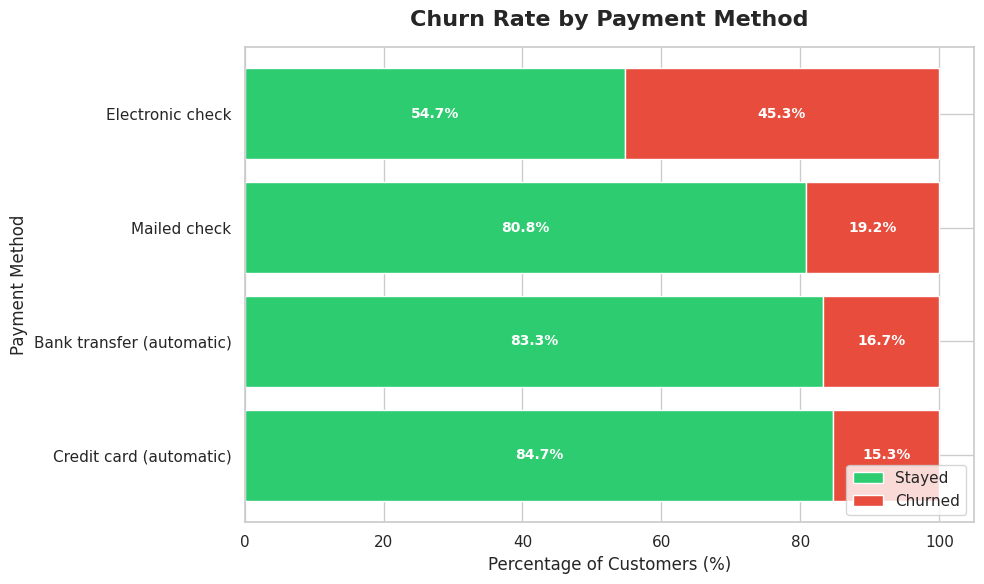

Chart 4 saved successfully!


In [21]:
# Chart 4 - Payment Method vs Churn (Horizontal Stacked Bar)

# Sort by churn rate so highest risk is at top
payment_sorted = payment_churn.sort_values('Yes', ascending=True)

# Build the chart
fig, ax = plt.subplots()
ax.barh(payment_sorted.index, payment_sorted['No'],
        color='#2ecc71', label='Stayed')
ax.barh(payment_sorted.index, payment_sorted['Yes'],
        left=payment_sorted['No'],
        color='#e74c3c', label='Churned')

# Add value labels
for i, (no, yes) in enumerate(zip(payment_sorted['No'],
                                   payment_sorted['Yes'])):
    ax.text(no/2, i, f'{no:.1f}%', ha='center',
            va='center', fontsize=10,
            fontweight='bold', color='white')
    ax.text(no + yes/2, i, f'{yes:.1f}%', ha='center',
            va='center', fontsize=10,
            fontweight='bold', color='white')

# Labels and titles
ax.set_title('Churn Rate by Payment Method', fontsize=16,
              fontweight='bold', pad=15)
ax.set_xlabel('Percentage of Customers (%)', fontsize=12)
ax.set_ylabel('Payment Method', fontsize=12)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('chart4_payment_churn.png', dpi=150)
plt.show()

print("Chart 4 saved successfully!")

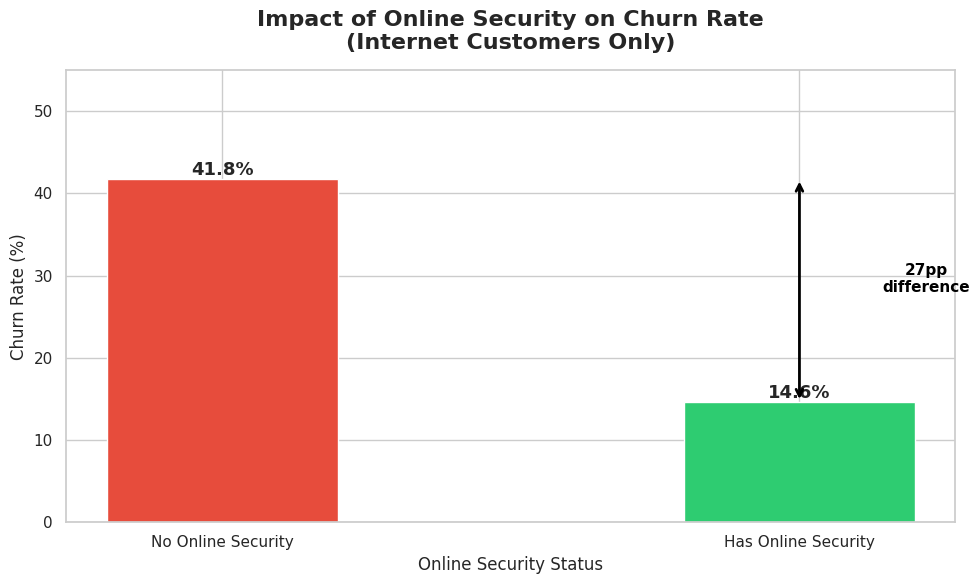

Chart 5 saved successfully!


In [22]:
# Chart 5 - Online Security vs Churn (Churn-Only Bar Chart)

# Data - churn rates only
categories = ['No Online Security', 'Has Online Security']
churn_rates = [41.78, 14.64]
colors = ['#e74c3c', '#2ecc71']

# Build the chart
fig, ax = plt.subplots()
bars = ax.bar(categories, churn_rates, color=colors, width=0.4)

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=13,
            fontweight='bold')

# Add a dramatic annotation showing the difference
ax.annotate('', xy=(1, 14.64), xytext=(1, 41.78),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(1.22, 28, '27pp\ndifference', ha='center',
        fontsize=11, fontweight='bold', color='black')

# Labels and titles
ax.set_title('Impact of Online Security on Churn Rate\n(Internet Customers Only)',
              fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xlabel('Online Security Status', fontsize=12)
ax.set_ylim(0, 55)

plt.tight_layout()
plt.savefig('chart5_security_churn.png', dpi=150)
plt.show()

print("Chart 5 saved successfully!")

In [23]:
import os

# Save the file
df.to_csv('Telco-Customer-Churn-Cleaned.csv', index=False)

# Confirm it exists
if os.path.exists('Telco-Customer-Churn-Cleaned.csv'):
    print("File exists! ✅")
    print("Location:", os.getcwd())
else:
    print("File not found ❌")

File exists! ✅
Location: /content
